## Step - 1 : Loading Necessary Packages

In [ ]:
#Packages
!pip install apyori  ## Installing apriori library
import numpy as np # linear algebra
import pandas as pd # Data pre-processing
import seaborn as sns # Required for plotting
import matplotlib.pyplot as plt # Required for plotting

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Step - 2 : Loading dataset

In [ ]:
# Input the Dataset Url
data_url = 'https://docs.google.com/spreadsheets/d/1O1MLdgdryVu4jBFF5CsVI7qS4qEEr_n_8ASZs3oS7sY/edit#gid=1118772156'
data_url_trf = data_url.replace('/edit#gid=', '/export?format=csv&gid=')

# Load the dataset
df_raw = pd.read_csv(data_url_trf)

# To get the Users Dataset Info
df_raw.head()

#The dataset that will be cleaned will be called as df_data
df_data =df_raw.copy()

In [ ]:
df_data.head()

,Member_number,Date,Item_description
0,1000,15-03-2015,Sausage
1,1000,15-03-2015,Whole Milk
2,1000,15-03-2015,Semi-Finished Bread
3,1000,15-03-2015,Yogurt
4,1000,24-06-2014,Whole Milk


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Member_number     38765 non-null  int64 
 1   Date              38765 non-null  object
 2   Item_description  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


## Step - 2 :Data Cleaning

### **I. Handling Missing Values**

In [ ]:
df_data.isnull().sum().sort_values(ascending=False)

Member_number       0
Date                0
Item_description    0
dtype: int64

There is no null value

### **II. Remove Duplicate Values**

In [ ]:
#Check duplicated data
df_data.duplicated().sum()

759

In [ ]:
df_data= df_data.drop_duplicates()
#Check duplicated data
df_data.duplicated().sum()

0

### **III. Convert Data Types**

In [ ]:
# To get the dataset Info
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38006 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Member_number     38006 non-null  int64 
 1   Date              38006 non-null  object
 2   Item_description  38006 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.2+ MB


In [ ]:
# Convert the data type of dataframe
# Convert member_number from Int to String
df_data['Member_number'] = df_data['Member_number'].astype(str)

# Convert Date types to datetime
df_data['Date'] = pd.to_datetime(df_data['Date'])


df_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 38006 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Member_number     38006 non-null  object        
 1   Date              38006 non-null  datetime64[ns]
 2   Item_description  38006 non-null  object        
dtypes: datetime64[ns](1), object(2)
memory usage: 1.2+ MB


<ipython-input-14-23880e28c7ea>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['Member_number'] = df_data['Member_number'].astype(str)
<ipython-input-14-23880e28c7ea>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['Date'] = pd.to_datetime(df_data['Date'])


## Step - 3 : EDA

##### **What is the total of the product?**

In [ ]:
all_products = df_data['Item_description'].unique()
print("Total products: {}".format(len(all_products)))

Total products: 167


#### **What is the top 5 customer ID which bought the most product**?

In [ ]:
df_data['Member_number'].value_counts().head()

3180    35
3737    33
3050    32
2051    31
2433    30
Name: Member_number, dtype: int64

#### **What is the TOP 5 items sold?**

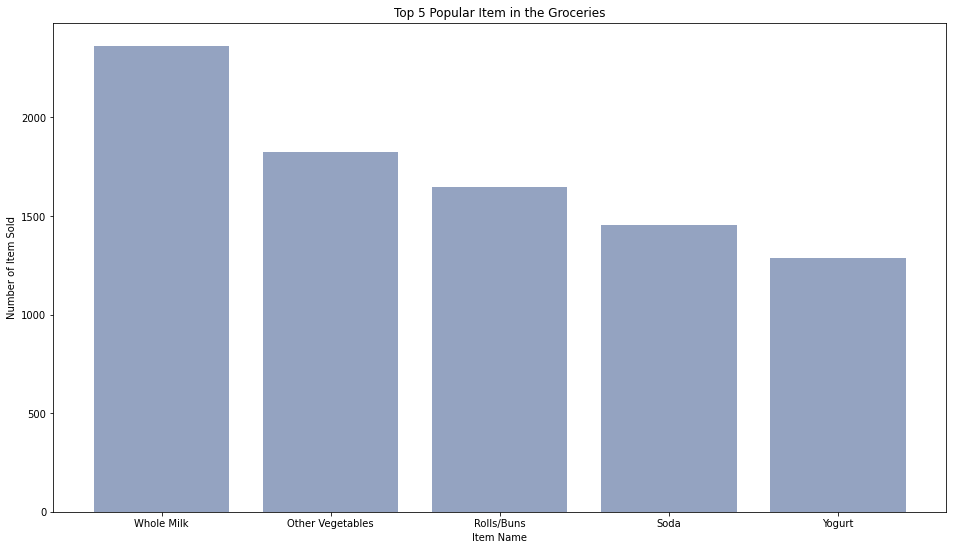

In [ ]:
## Creating distribution of Item Sold

Item_distr = df_data.groupby(by = "Item_description").size().reset_index(name='Frequency').sort_values(by = 'Frequency',ascending=False).head(5)

## Declaring variables

bars = Item_distr["Item_description"]
height = Item_distr["Frequency"]
x_pos = np.arange(len(bars))

## Defining Figure Size

plt.figure(figsize=(16,9))

# Create bars
plt.bar(x_pos, height, color=(0.3, 0.4, 0.6, 0.6))

# Add title and axis names
plt.title("Top 5 Popular Item in the Groceries")
plt.xlabel("Item Name")
plt.ylabel("Number of Item Sold")

# Create names on the x-axis
plt.xticks(x_pos, bars)

# Show graph
plt.show()

#### **How is the sales trend ?**

In [ ]:
## Setting date as index for plotting purpose
df_date=df_data.set_index(['Date'])
df_date.head()

,Member_number,Item_description
Date,,
2015-03-15,1000,Sausage
2015-03-15,1000,Whole Milk
2015-03-15,1000,Semi-Finished Bread
2015-03-15,1000,Yogurt
2014-06-24,1000,Whole Milk


[Text(0, 0.5, 'Number of Items Sold'), Text(0.5, 0, 'Date')]

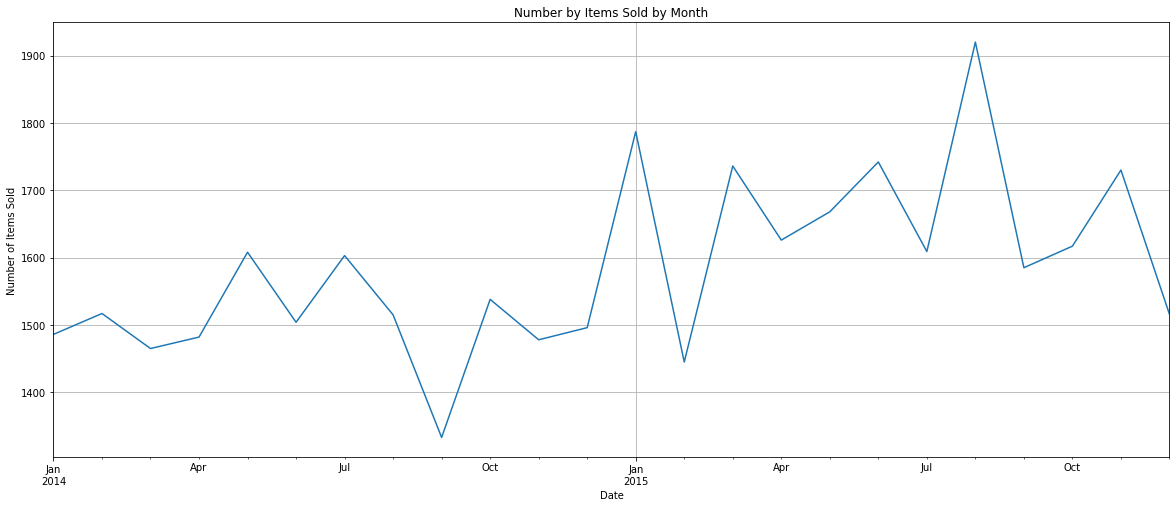

In [ ]:
df_date.resample("M")['Item_description'].count().plot(figsize = (20,8), grid = True, title = "Number by Items Sold by Month").set(xlabel = "Date", ylabel = "Number of Items Sold")

## Step - 5 : Apriori Implementation


**apriori algorithm.**

We will use apriori algorithm to find the best product combination.
It's used to identify the most frequently occurring elements and meaningful associations in a dataset.
We can decide the number of support, confidence and lift based on historical data as baseline.


We will deep dive the data to understand the relationship between product X and product Y on each customer

#### Data Preparation

In [ ]:
# Selecting only required variables for modelling
customer = df_data[["Member_number", "Item_description"]].sort_values(by = "Member_number", ascending = False)

# Removing extra white spaces
customer['Item_description'] = customer['Item_description'].str.strip()
customer

,Member_number,Item_description
38764,5000,Semi-Finished Bread
38763,5000,Onions
38762,5000,Other Vegetables
38761,5000,Root Vegetables
38760,5000,Fruit/Vegetable Juice
...,...,...
9,1000,Sausage
10,1000,Hygiene Articles
11,1000,Soda
12,1000,Pickled Vegetables


####  Create Transaction list

Let's grouping the items which bought by each customer.

In [ ]:
transactions = [a[1]['Item_description'].tolist()
 ## Combing all the items in list format for each cutomer
for a in list(customer.groupby(['Member_number']))]

In [ ]:
transactions

[['Canned Beer',
  'Semi-Finished Bread',
  'Yogurt',
  'Whole Milk',
  'Pastry',
  'Salty Snack',
  'Whole Milk',
  'Misc. Beverages',
  'Sausage',
  'Hygiene Articles',
  'Soda',
  'Pickled Vegetables',
  'Sausage'],
 ['Curd',
  'Frankfurter',
  'Frankfurter',
  'Beef',
  'Sausage',
  'Whole Milk',
  'Soda',
  'White Bread',
  'Whole Milk',
  'Soda',
  'Whipped/Sour Cream',
  'Rolls/Buns'],
 ['Butter',
  'Tropical Fruit',
  'Butter Milk',
  'Frozen Vegetables',
  'Sugar',
  'Specialty Chocolate',
  'Other Vegetables',
  'Whole Milk'],
 ['Dental Care',
  'Rolls/Buns',
  'Frozen Meals',
  'Detergent',
  'Rolls/Buns',
  'Root Vegetables',
  'Sausage'],
 ['Frozen Fish',
  'Pip Fruit',
  'Root Vegetables',
  'Canned Beer',
  'Rolls/Buns',
  'Other Vegetables',
  'Other Vegetables',
  'Hygiene Articles',
  'Whole Milk',
  'Whole Milk',
  'Whole Milk',
  'Red/Blush Wine',
  'Rolls/Buns',
  'Chocolate',
  'Chocolate',
  'Cling Film/Bags',
  'Pastry',
  'Tropical Fruit',
  'Packaged Fruit/Veg

#### Train Model

Importing and Setting the apriori options
1. Minimum Support = 0.002
2. Minimum Confidence = 0.05
3. Minimum Lift = 3
4. Lenght = 2 (Since we will find 2 combination of product)

In [ ]:
from apyori import apriori ## Importing apriori package
rules = apriori(transactions = transactions, min_support = 0.002, min_confidence = 0.05, min_lift = 3, min_length = 2, max_length = 2) ## Model Creation

In [ ]:
results = list(rules)

In [ ]:
results

[RelationRecord(items=frozenset({'Beef', 'Potato Products'}), support=0.002565418163160595, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Potato Products'}), items_add=frozenset({'Beef'}), confidence=0.4545454545454546, lift=3.8021849395239955)]),
 RelationRecord(items=frozenset({'Coffee', 'Canned Fruit'}), support=0.002308876346844536, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Canned Fruit'}), items_add=frozenset({'Coffee'}), confidence=0.4285714285714286, lift=3.7289540816326534)]),
 RelationRecord(items=frozenset({'Meat Spreads', 'Domestic Eggs'}), support=0.0035915854284248334, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Meat Spreads'}), items_add=frozenset({'Domestic Eggs'}), confidence=0.4, lift=3.0042389210019267)]),
 RelationRecord(items=frozenset({'Flour', 'Mayonnaise'}), support=0.002308876346844536, ordered_statistics=[OrderedStatistic(items_base=frozenset({'Flour'}), items_add=frozenset({'Mayonnaise'}), confidence=0.0633802816

#### Result Customization

In [ ]:
## Creating user-defined function for arranging the results obtained from model into readable format

def inspect(results):
    x         = [tuple(result[2][0][0])[0] for result in results]
    y         = [tuple(result[2][0][1])[0] for result in results]
    supports    = [result[1] for result in results]
    confidences = [result[2][0][2] for result in results]
    lifts       = [result[2][0][3] for result in results]
    return list(zip(x, y, supports, confidences, lifts))
resultsinDataFrame = pd.DataFrame(inspect(results), columns = ['1st Product', '2nd Product', 'Support', 'Confidence', 'Lift'])

In [ ]:
resultsinDataFrame.nlargest(n=7, columns="Confidence").reset_index(drop=True) ## Showing best possible scenarios

,1st Product,2nd Product,Support,Confidence,Lift
0,Potato Products,Beef,0.002565,0.454545,3.802185
1,Canned Fruit,Coffee,0.002309,0.428571,3.728954
2,Meat Spreads,Domestic Eggs,0.003592,0.400000,3.004239
3,Kitchen Towels,Uht-Milk,0.002309,0.300000,3.821569
4,Rice,Napkins,0.003079,0.244898,3.011395
5,Sparkling Wine,Waffles,0.002565,0.217391,3.150154
6,Flour,Mayonnaise,0.002309,0.063380,3.338599


**Insight:**
- All the product combination have low support which is below 0.35%, it means that the itemsets are not popular among the customer.
- The possibility


Product bundling recommendation:

